# Descriptive Analysis and manipulation of data structures

In the previous notebook, we simulated a dataset directly in R to illustrate basic concepts. In practice, however, data are typically obtained from external sources—for example, from open research repositories.

In this notebook, we will work with real-world data from *Midlife in the United States* (MIDUS), a large-scale longitudinal study examining health, well-being, and aging. MIDUS was launched in the mid-1990s and has since included multiple follow-up waves as well as refresher samples, allowing researchers to track developmental and health-related changes over time.

The figure below, adapted from the MIDUS homepage, provides an overview of the study design.

![alt text](https://midus.wisc.edu/wp-content/uploads/2025/02/MIDUS_timeline.png)

Obtaining data from MIDUS is straightforward. You first need to [register as a user](https://midus.wisc.edu/data-access/). After registration, you can access the online data explorer, browse available datasets, and select variables of interest. These can be added to a “basket” and downloaded in various formats, including CSV files for direct use in R or other statistical software.

## An example research question

In this example, I am interested in examining whether hearing thresholds are associated with **brain age**, more specifically with *predicted age difference* (PAD). Within MIDUS, PAD is derived from structural MRI data and reflects the extent to which an individual’s predicted brain age deviates from their chronological age. Positive values indicate relatively accelerated brain aging, whereas negative values indicate relatively preserved brain structure.

In addition, I am interested in whether individuals with hearing loss report higher levels of depressed affect.

For illustration purposes, I downloaded a small, provisional subset of MIDUS data. The goal of this notebook is not to conduct a full analysis, but to demonstrate essential steps in working with real-world data—such as importing, cleaning, restructuring, and exploring variables descriptively.

We will examine the substantive research questions in greater depth in the next notebook.

## Reading and filtering the data

There are various methods to read, explore and filter data sets in R. We will use tools provided by **tidyverse**, which is a collection of R packages designed for modern data science. Instead of being a single package, it is a coherent ecosystem of tools that share a common philosophy, syntax, and data structure. You can find more information [here](https://tidyverse.org).

When loading tidyverse, the relevant libraries for us are within *readr* and *dplyr*. Furthermore, we will use ggplot for visualizations.

In [1]:
library(tidyverse)


is_colab <- function() {
  file.exists("/content")
}

# Load the saved R data (creates `selected_data`)
if(is_colab() == TRUE) {
    # Running in Colab, use the path for Colab
    midus_data <- readr::read_csv("./HealthyAgingR_data/midus_data.csv") #adding readr makes it clear where read_csv is coming from, as there are other tools with similar function names
    midus_meta <- readr::read_csv("./HealthyAgingR_data/midus_meta.csv",locale = readr::locale(encoding = "UTF-16LE")
)
} else {
    # Running locally, use the local path
    midus_data <- readr::read_csv("./data/midus_data.csv") #adding readr makes it clear where read_csv is coming from, as there are other tools with similar function names
    midus_meta <- readr::read_csv("./data/midus_meta.csv",locale = readr::locale(encoding = "UTF-16LE")
)
}

# quick check
glimpse(midus_data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 11003 Columns: 52
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (52): MIDUSID, SAMPLMAJ, M2ID, MRID, B1PRSEX, B1PRAGE_2019, B1PB1, B1SA1...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 68 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (

Rows: 11,003
Columns: 52
$ MIDUSID      <dbl> 10001, 10002, 10004, 10005, 10006, 10007, 10008, 10009, 1…
$ SAMPLMAJ     <dbl> 2, 1, 1, 3, 3, 3, 3, 1, 3, 2, 1, 1, 3, 1, 4, 4, 1, 1, 1, …
$ M2ID         <dbl> 10001, 10002, 10004, 10005, 10006, 10007, 10008, 10009, 1…
$ MRID         <dbl> NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, Na…
$ B1PRSEX      <dbl> 1, 1, NA, 2, 2, NA, NA, NA, 1, 2, NA, 1, 2, NA, 1, 1, 1, …
$ B1PRAGE_2019 <dbl> 61, 69, NA, 80, 60, NA, NA, NA, 55, 52, NA, 57, 53, NA, 4…
$ B1PB1        <dbl> 9, 12, NA, 3, 6, NA, NA, NA, 5, 11, NA, 5, 5, NA, 9, 5, 9…
$ B1SA1        <dbl> 7, 8, NA, 8, -1, NA, NA, NA, 9, 9, NA, -1, 7, NA, -1, 9, …
$ B1PDEPAD     <dbl> 0, 0, NA, 0, 1, NA, NA, NA, 0, 1, NA, 0, 0, NA, 0, 0, 0, …
$ C1PRSEX      <dbl> 1, 1, NA, NA, NA, NA, NA, NA, NA, 2, NA, NA, 2, NA, NA, N…
$ C1PB1        <dbl> 9, 12, NA, NA, NA, NA, NA, NA, NA, 11, NA, NA, 5, NA, NA,…
$ C1SA1        <dbl> 8, -1, NA, NA, NA, NA, NA, NA, NA, 9, NA, NA, 6, NA, NA, …
$ C1PDEPAD     

*midus_data* is a data frame containing the actual data. As you can see it contains many columns with cryptic names. We probably won't need all of them. The midus_meta data frame contains metadata for us to make sense of the column names. We will use it to select the relavant parts.

Let's first select the the relevant column names based on some information. We will use *dplyr* tools *filter* and *select*, implementing a “pipe“ of commands.

In [2]:
hearing_vars <- midus_meta %>%
  filter(
    str_detect(Dataset, "MR1"),
    str_detect(Label, regex("hearing", ignore_case = TRUE))
  ) %>%
  select(Name, Label)

hearing_vars

Name,Label
<chr>,<chr>
RA5OL1,Hearing Test - Left Ear 250Hz (lowest dB level at which Pp could hear tone)
RA5OL2,Hearing Test - Left Ear 500Hz (lowest dB level at which Pp could hear tone)
RA5OL3,Hearing Test - Left Ear 1000Hz (lowest dB level at which Pp could hear tone)
RA5OR1,Hearing Test - Right Ear 250Hz (lowest dB level at which Pp could hear tone)
RA5OR2,Hearing Test - Right Ear 500Hz (lowest dB level at which Pp could hear tone)
RA5OR3,Hearing Test - Right Ear 1000Hz (lowest dB level at which Pp could hear tone)


Think of a “pipe“ as a sequence of “and-then“-commands. So in the above example:
* Take the midus_meta data frame AND THEN
* filter the data by searching for data sets that contain “MR1“ (i.e. from the Midus Refresher 1) and where the “Label“ indicates that hearing was measured AND THEN
* select the relevant Names along with the Labels

There are multiple values. We will average over all hearing values and get something like a global hearing score (the higher the worse). Operations on the data frame can be done using *mutate*, and calculations can be added as another column (here hearing_avg).

In [8]:
midus_data <- midus_data %>%
    mutate(
        hearing_avg = rowMeans(
            select(., all_of(hearing_vars$Name)),
            na.rm = FALSE
        )
    )



Now let's find the variable names for predicted brain age. As there are multiple predicted brain age measures, we will pick the one from Midus 1 Refresher.

In [9]:
brain_age_vars <- midus_meta %>%
  filter(
    str_detect(Dataset, "MR1"),
    str_detect(Label, regex("brain-predicted age", ignore_case = TRUE))
  ) %>%
  select(Name, Label)

brain_age_vars

Name,Label
<chr>,<chr>
RA5EBP,Brain-Predicted Age (PMID: 36595679)


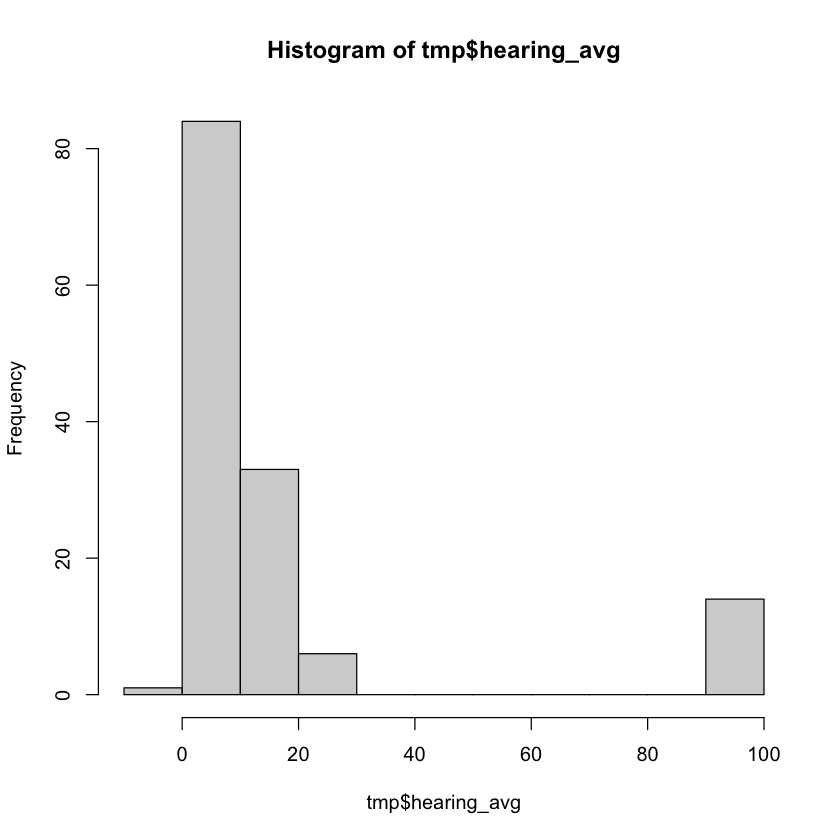

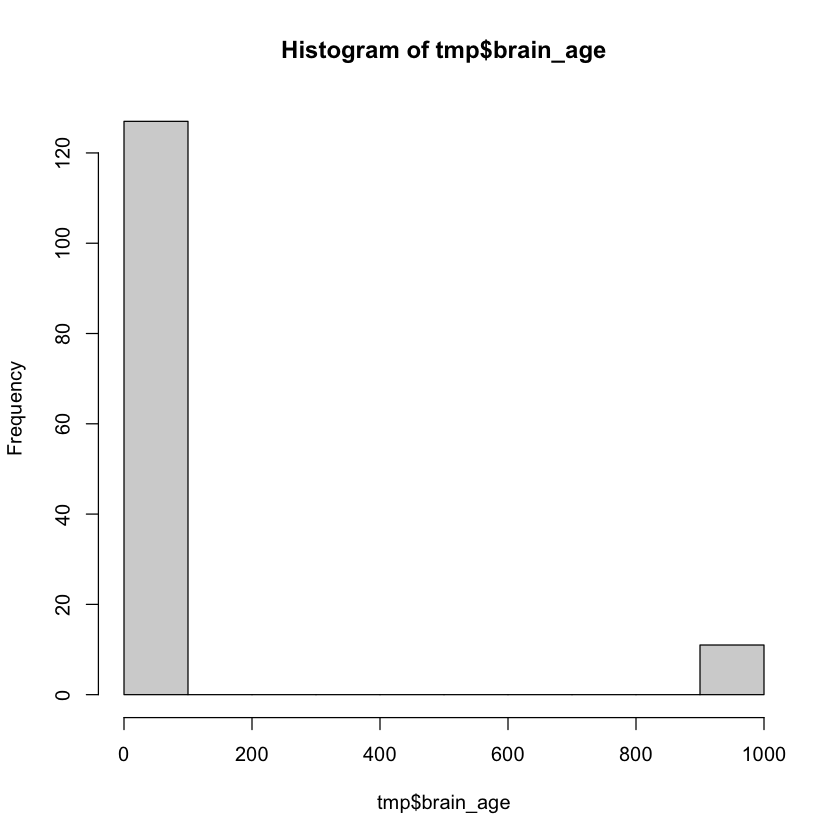

In [10]:
tmp <- midus_data %>%
    select(hearing_avg, all_of(brain_age_vars$Name)) %>%
    rename("brain_age" = 2)

hist(tmp$hearing_avg)
hist(tmp$brain_age)


You can see that there are some extreme values, that are not plausible. This needs to be taken into account when cleaning the data frames. E.g. here we could decide to discard all hearing values beyond 80 and brain age values beyond 200.

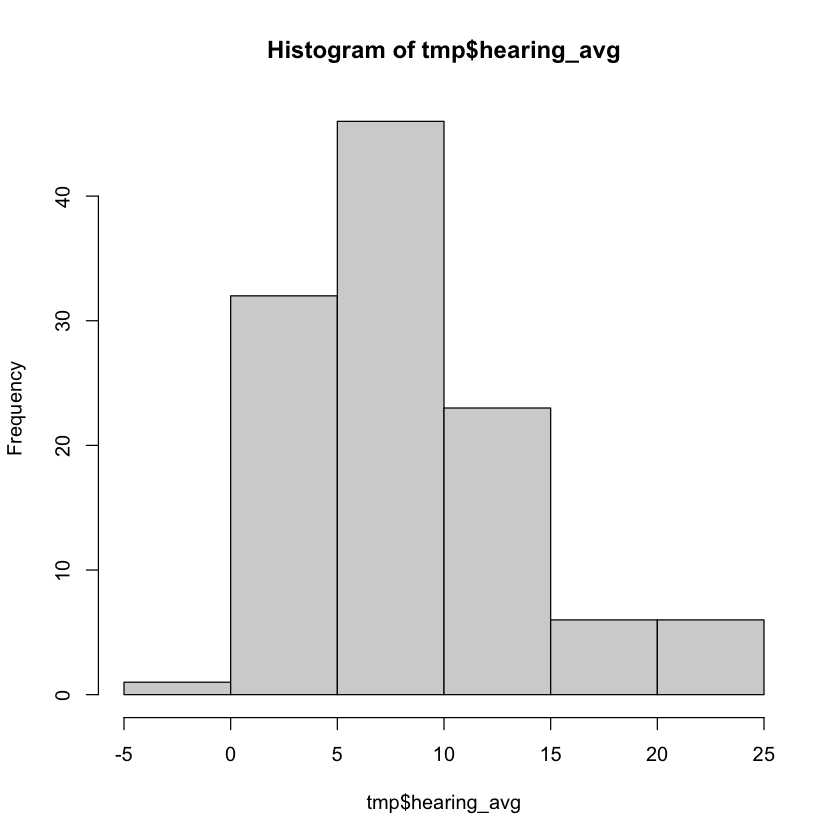

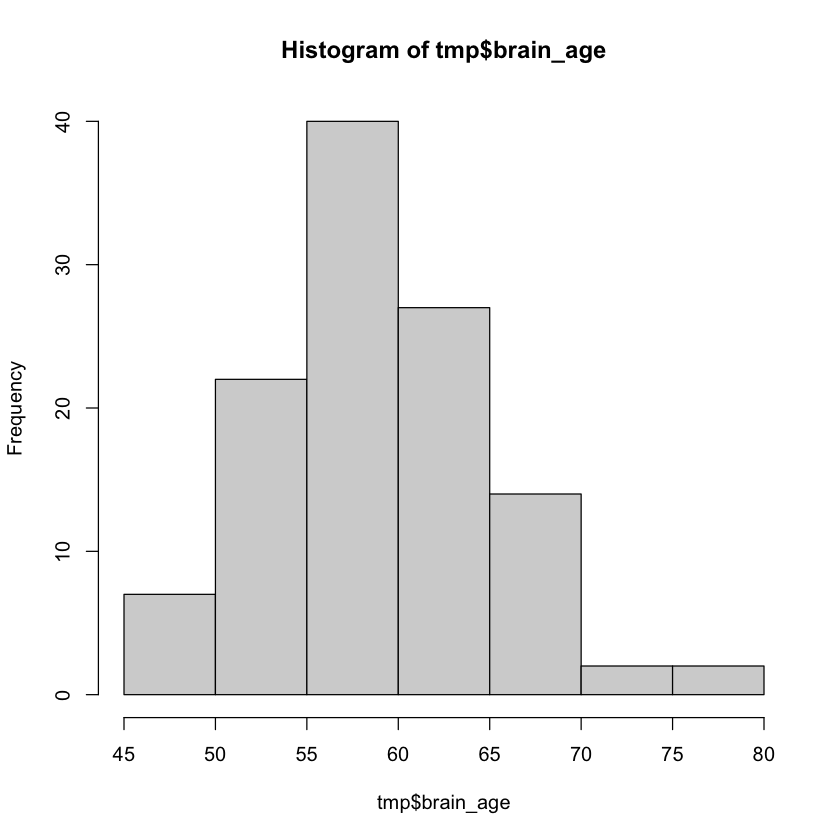

In [20]:
## remove implausible extremes before further work
tmp <- tmp %>%
    filter(hearing_avg <= 80,
           brain_age  <= 200)

# re‑inspect the distributions
hist(tmp$hearing_avg)
hist(tmp$brain_age)

Now let's create a scatterplot.

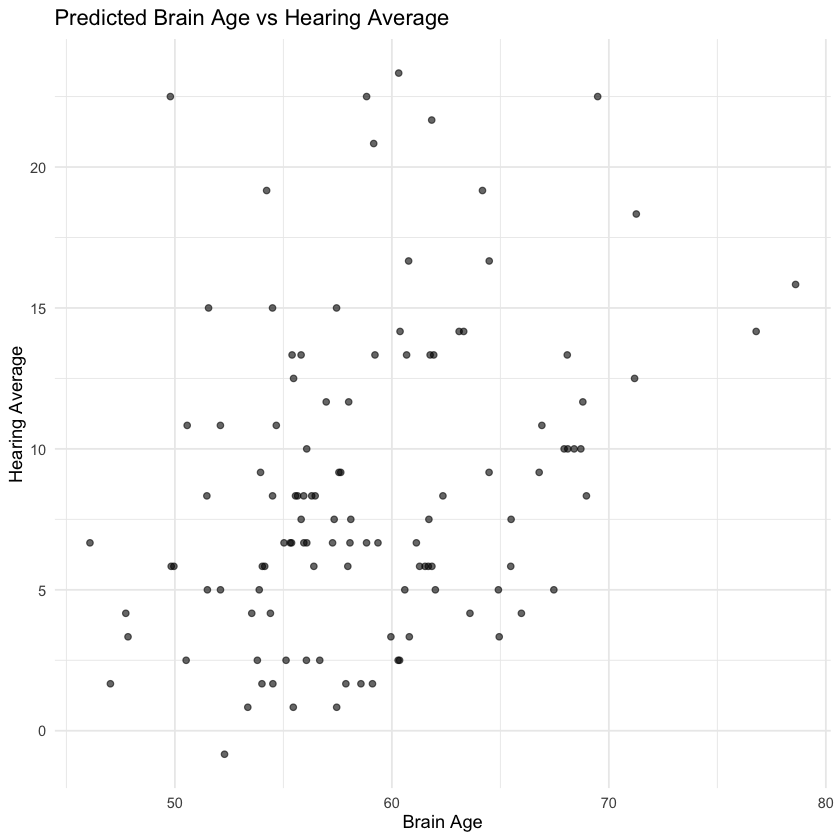

In [21]:
ggplot(tmp, aes(x = brain_age, y = hearing_avg)) +
    geom_point(alpha = 0.6) +
    labs(
        x = "Brain Age",
        y = "Hearing Average",
        title = "Predicted Brain Age vs Hearing Average"
    ) +
    theme_minimal()

Ok. We can appreciate that older Brain Age seems related to worse hearing. This is not surprising, as Brain Age will be highly correlated with chronological age. We want the actual deviances from chronological age and also some other variables we want to “control for“. So let's make a more comprehensive selection.

First we will find further relevant variable names. We will take the values from the Midus Refresher 1, as it is quite complete. Let's create a little function.

In [ ]:
find_var <- function(keywords) {
  midus_meta %>%
    filter(
      str_detect(Dataset, regex("MR1", ignore_case = TRUE)),
      str_detect(Label,   regex(keywords, ignore_case = TRUE))
    ) %>%
    slice(1) %>%            # take the first match (keep simple)
    select(Name, Label, Dataset)
}

age_var        <- find_var("calculated age")
sex_var        <- find_var("sex|gender")
stress_var     <- find_var("stress")
health_var     <- find_var("health")
education_var     <- find_var("education")
depression_var <- find_var("depress")

In [32]:
age_var

Name,Label,Dataset
<chr>,<chr>,<chr>
RA5EBP,Brain-Predicted Age (PMID: 36595679),MR1P5


Now let's select the data.

In [23]:
selected_data <- midus_data %>%
  select(
    age          = all_of(age_var$Name),
    sex          = all_of(sex_var$Name),
    education_var = all_of(education_var$Name),
    stress       = all_of(stress_var$Name),
    rated_health = all_of(health_var$Name),
    depression   = all_of(depression_var$Name),
    brain_age    = all_of(brain_age_vars$Name),
    hearing_avg  = hearing_avg
  ) %>%
  filter(
    !is.na(age),
    !is.na(brain_age),
    !is.na(hearing_avg)
  )

#remove implausible extremes before further work
selected_data <- selected_data %>%
    filter(hearing_avg <= 80,
           brain_age  <= 200) %>%
    mutate(
        BAG = age - brain_age) # calculate brain age gap (BAG) as chronological age minus predicted brain age

#Visualize brain age gaps
hist(selected_data$BAG)


ERROR: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `!is.na(age)`.
[1mCaused by error:[22m
[33m![39m object 'age' not found


Finally, let's save the data for further analysis.

In [32]:
save(selected_data, file = "./data/selected_data.Rdata")